In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

Shape of Dataset:
(891, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df['Cabin'].fillna("Unknown", inplace=True)

/tmp/ipykernel_963/1415249874.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_963/1415249874.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [6]:
print("Duplicates Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [7]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Data Type': df.dtypes.values
})

summary

,Column,Missing Values,Data Type
0,PassengerId,0,int64
1,Survived,0,int64
2,Pclass,0,int64
3,Name,0,object
4,Sex,0,object
5,Age,0,float64
6,SibSp,0,int64
7,Parch,0,int64
8,Ticket,0,object
9,Fare,0,float64


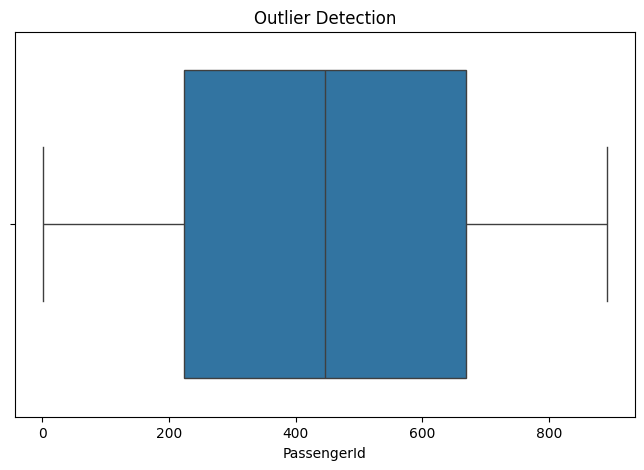

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df.select_dtypes(include=np.number).iloc[:,0]
)

plt.title("Outlier Detection")
plt.show()

In [15]:
print("Data Types Check:")
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [16]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

PassengerId: 891 unique values
Survived: 2 unique values
Pclass: 3 unique values
Name: 891 unique values
Sex: 2 unique values
Age: 89 unique values
SibSp: 7 unique values
Parch: 7 unique values
Ticket: 681 unique values
Fare: 248 unique values
Cabin: 148 unique values
Embarked: 3 unique values


In [18]:
stats_report = df.describe(include='all')

stats_report.to_csv(
    "statistical_report.csv"
)

stats_report

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,148,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,Unknown,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,687,646
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.002015,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,29.699118,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [19]:
print("========== PROJECT SUMMARY ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Missing Values:")
print(df.isnull().sum().sum())

print("Duplicate Rows:")
print(df.duplicated().sum())

print("====================================")
print("Data Cleaning Completed Successfully")

========== PROJECT SUMMARY ==========
Rows: 891
Columns: 12
Missing Values:
0
Duplicate Rows:
0
Data Cleaning Completed Successfully


In [20]:
report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Data Type": df.dtypes.values,
    "Unique Values": df.nunique().values
})

report

,Column,Missing Values,Data Type,Unique Values
0,PassengerId,0,int64,891
1,Survived,0,int64,2
2,Pclass,0,int64,3
3,Name,0,object,891
4,Sex,0,object,2
5,Age,0,float64,89
6,SibSp,0,int64,7
7,Parch,0,int64,7
8,Ticket,0,object,681
9,Fare,0,float64,248


In [23]:
report.to_csv("automation_report.csv", index=False)

In [27]:

def automate_cleaning(data):

    for col in data.select_dtypes(include=np.number):
        data[col].fillna(data[col].mean(), inplace=True)

    data.drop_duplicates(inplace=True)

    report = pd.DataFrame({
        "Column": data.columns,
        "Missing Values": data.isnull().sum().values
    })

    report.to_csv("automation_report.csv", index=False)

    return data

cleaned_df = automate_cleaning(df)



/tmp/ipykernel_963/49320817.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


In [28]:
cleaned_df.to_csv("cleaned_dataset.csv", index=False)

print("Automation Completed Successfully")

Automation Completed Successfully
